# Parte 2: Clasificación de Texto con RNN y LSTM
## Mateo Llanos - Sofia Gonzalez - Nicolas Hurtado

**Dataset:** 50,000 reseñas de películas en inglés (25,000 train / 25,000 test), 2 clases: positivo y negativo.  
**Objetivo:** Clasificar el sentimiento de reseñas usando primero una **RNN simple** y luego una **LSTM**, comparando ambas arquitecturas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

tf.random.set_seed(42)
np.random.seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.21.0


---
## i. Conjunto de Datos: IMDB

In [2]:
NUM_WORDS = 10_000   # tamaño del vocabulario

print("Cargando dataset IMDB...")
(X_train_raw, y_train), (X_test_raw, y_test) = imdb.load_data(num_words=NUM_WORDS)

print(f"Train : {len(X_train_raw):,} reseñas")
print(f"Test  : {len(X_test_raw):,}  reseñas")
print(f"Clases: 0=Negativa | 1=Positiva")
print(f"Balance train: {np.mean(y_train)*100:.1f}% positivas")
print(f"Vocabulario   : {NUM_WORDS:,} palabras")

Cargando dataset IMDB...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train : 25,000 reseñas
Test  : 25,000  reseñas
Clases: 0=Negativa | 1=Positiva
Balance train: 50.0% positivas
Vocabulario   : 10,000 palabras


In [3]:
# Decodificar algunas reseñas para mostrar ejemplos legibles
word_index   = imdb.get_word_index()
reverse_index = {v+3: k for k, v in word_index.items()}
reverse_index.update({0: '<PAD>', 1: '<START>', 2: '<UNK>', 3: '<UNUSED>'})

def decode_review(encoded):
    return ' '.join(reverse_index.get(i, '?') for i in encoded)

print("=" * 70)
print("EJEMPLOS DEL DATASET")
print("=" * 70)
for i in range(4):
    texto   = decode_review(X_train_raw[i])
    clase   = 'POSITIVA' if y_train[i] == 1 else 'NEGATIVA'
    palabras = len(X_train_raw[i])
    print(f"\n[Reseña {i+1}] Clase: {clase} | Palabras: {palabras}")
    print(f"  {texto[:300]}...")
    print("-" * 70)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EJEMPLOS DEL DATASET

[Reseña 1] Clase: POSITIVA | Palabras: 218
  <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the...
----------------------------------------------------------------------

[Reseña 2] Clase: NEGATIVA | Palabras: 189
  <START> big hair big boobs bad music and a giant safety pin these are the words to best describe this terrible movie i love cheesy horror movies and i've seen hundreds but this had got to be on of the worst ever made the plot is paper thin and ridiculous the acting is an abomination the script is co...
----------------------------------------------------------------------

[Reseña 3] Clase: NEGATIVA | Palabras: 141
  <START> this has to be one of the worst fi

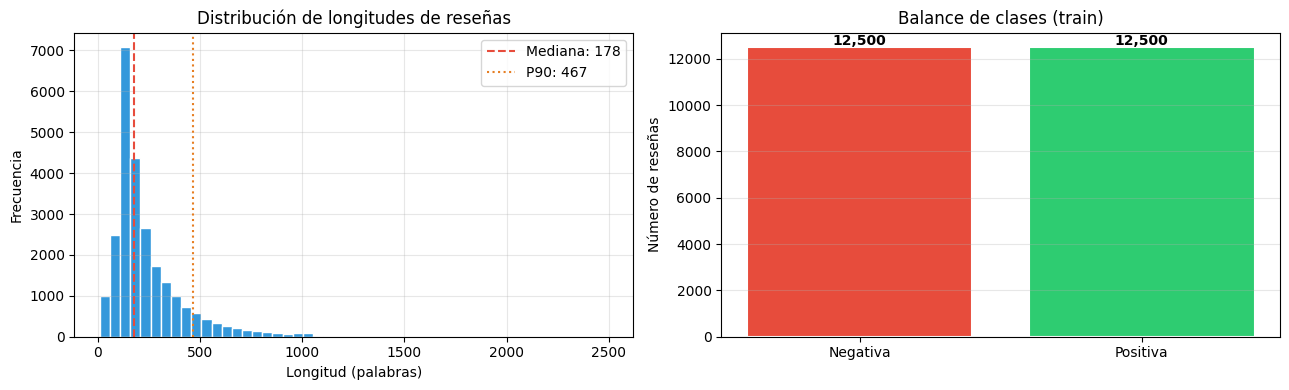

Longitud promedio : 239 palabras
Longitud mediana  : 178 palabras
Percentil 90      : 467 palabras
Máximo            : 2494 palabras


In [4]:
# Distribución de longitudes de reseñas
longitudes = [len(x) for x in X_train_raw]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(longitudes, bins=50, color='#3498db', edgecolor='white')
axes[0].axvline(np.median(longitudes), color='#e74c3c', linestyle='--',
                label=f'Mediana: {np.median(longitudes):.0f}')
axes[0].axvline(np.percentile(longitudes, 90), color='#e67e22', linestyle=':',
                label=f'P90: {np.percentile(longitudes, 90):.0f}')
axes[0].set_xlabel('Longitud (palabras)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de longitudes de reseñas')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Balance de clases
clases, conteos = np.unique(y_train, return_counts=True)
nombres_clase   = ['Negativa', 'Positiva']
axes[1].bar(nombres_clase, conteos, color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
for i, c in enumerate(conteos):
    axes[1].text(i, c + 100, f'{c:,}', ha='center', fontweight='bold')
axes[1].set_ylabel('Número de reseñas')
axes[1].set_title('Balance de clases (train)')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('distribucion_dataset_texto.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Longitud promedio : {np.mean(longitudes):.0f} palabras")
print(f"Longitud mediana  : {np.median(longitudes):.0f} palabras")
print(f"Percentil 90      : {np.percentile(longitudes, 90):.0f} palabras")
print(f"Máximo            : {max(longitudes)} palabras")

---
## ii. Preprocesamiento

**Pasos:**

1. **Vocabulario:** ya construido por Keras con las 10,000 palabras más frecuentes. Palabras fuera del vocabulario se convierten en `<UNK>`. El tamaño del vocabulario controla el balance entre cobertura del lenguaje y la dimensión del embedding.

2. **Longitud máxima (`MAX_LEN`):** el 90% de las reseñas tiene menos de ~600 palabras. Usaremos `MAX_LEN=300` para cubrir la mediana (~240 palabras) sin que el padding infle excesivamente las secuencias cortas.

3. **Padding:** las secuencias más cortas que MAX_LEN se rellenan con ceros al final (`post`), y las más largas se truncan al inicio (`pre`) para conservar el final de la reseña donde suelen estar las conclusiones de la crítica.

In [5]:
MAX_LEN = 300   # longitud máxima de secuencia

X_train = pad_sequences(X_train_raw, maxlen=MAX_LEN, padding='post', truncating='pre')
X_test  = pad_sequences(X_test_raw,  maxlen=MAX_LEN, padding='post', truncating='pre')

print("Preprocesamiento completado:")
print(f"  Vocabulario (NUM_WORDS) : {NUM_WORDS:,}")
print(f"  Longitud máxima         : {MAX_LEN} tokens")
print(f"  X_train shape           : {X_train.shape}")
print(f"  X_test  shape           : {X_test.shape}")
print(f"  Tipo de datos           : {X_train.dtype}")
print()
print("Cada fila es una reseña representada como secuencia de enteros")
print("Ejemplo (primeros 20 tokens):", X_train[0, :20])

Preprocesamiento completado:
  Vocabulario (NUM_WORDS) : 10,000
  Longitud máxima         : 300 tokens
  X_train shape           : (25000, 300)
  X_test  shape           : (25000, 300)
  Tipo de datos           : int32

Cada fila es una reseña representada como secuencia de enteros
Ejemplo (primeros 20 tokens): [   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25]


---
## iii. Modelo 1 — RNN Simple

**Arquitectura:** `Embedding → SimpleRNN → Dense(softmax)`

- **Embedding (10000 → 64 dims):** convierte cada índice entero en un vector denso de 64 dimensiones. La capa aprende representaciones semánticas durante el entrenamiento (palabras similares → vectores cercanos). Elegimos 64 dims como balance entre capacidad expresiva y velocidad de entrenamiento.

- **SimpleRNN (64 unidades):** procesa la secuencia token a token, manteniendo un estado oculto que "recuerda" el contexto anterior. Limitación: el gradiente puede desvanecerse en secuencias largas (problema de larga dependencia).

- **Dense(1, sigmoid):** capa de salida binaria (positivo/negativo).

Se prueban dos configuraciones de hiperparámetros: número de unidades en la RNN (32 vs 64).

In [6]:
EMBED_DIM   = 64
BATCH_SIZE  = 64
EPOCHS_RNN  = 10

def build_rnn(units=64, embed_dim=EMBED_DIM):
    model = keras.Sequential([
        layers.Embedding(NUM_WORDS, embed_dim, input_length=MAX_LEN),
        layers.SimpleRNN(units),
        layers.Dense(1, activation='sigmoid')
    ], name=f'RNN_{units}units')
    return model

# Mostrar arquitectura del modelo con 64 unidades
rnn_demo = build_rnn(64)
rnn_demo.summary()

Model: "RNN_64units"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Hiperparámetros probados en RNN

| Config | Unidades SimpleRNN | Learning Rate | Justificación |
|--------|--------------------|---------------|---------------|
| RNN-A  | 32                 | 0.001         | Modelo más ligero, menos parámetros, más rápido |
| RNN-B  | 64                 | 0.001         | Mayor capacidad de memoria recurrente |

In [7]:
def entrenar(model, nombre, epochs=EPOCHS_RNN):
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    t0 = time.time()
    hist = model.fit(
        X_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=epochs,
        validation_split=0.20,
        verbose=1
    )
    elapsed = time.time() - t0
    print(f"\n{nombre} entrenado en {elapsed:.0f}s")
    return model, hist, elapsed

print("=== RNN Config-A: 32 unidades ===")
rnn_A, hist_rnnA, t_rnnA = entrenar(build_rnn(32), 'RNN-A (32 units)')

=== RNN Config-A: 32 unidades ===
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.5082 - loss: 0.6916 - val_accuracy: 0.5228 - val_loss: 0.6855
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - accuracy: 0.5889 - loss: 0.6326 - val_accuracy: 0.5260 - val_loss: 0.7043
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6129 - loss: 0.5733 - val_accuracy: 0.5134 - val_loss: 0.7444
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6349 - loss: 0.5312 - val_accuracy: 0.5098 - val_loss: 0.7797
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6437 - loss: 0.5212 - val_accuracy: 0.5206 - val_loss: 0.7969
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6381 - loss: 0.5232 - val_accuracy: 0.5056 - val_loss: 0.8022
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.6026 - loss: 0.5860 - val_accuracy: 0.5182 - val_loss: 0.7852
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - 

In [8]:
print("=== RNN Config-B: 64 unidades ===")
rnn_B, hist_rnnB, t_rnnB = entrenar(build_rnn(64), 'RNN-B (64 units)')

=== RNN Config-B: 64 unidades ===
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.5087 - loss: 0.6922 - val_accuracy: 0.5228 - val_loss: 0.6872
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.5621 - loss: 0.6712 - val_accuracy: 0.5172 - val_loss: 0.6884
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.5594 - loss: 0.6730 - val_accuracy: 0.5222 - val_loss: 0.6800
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5709 - loss: 0.6501 - val_accuracy: 0.5320 - val_loss: 0.6868
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.5730 - loss: 0.6349 - val_accuracy: 0.5210 - val_loss: 0.6855
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5882 - loss: 0.6192 - val_accuracy: 0.5262 - val_loss: 0.6887
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5932 - loss: 0.6065 - val_accuracy: 0.5396 - val_loss: 0.6964
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - 

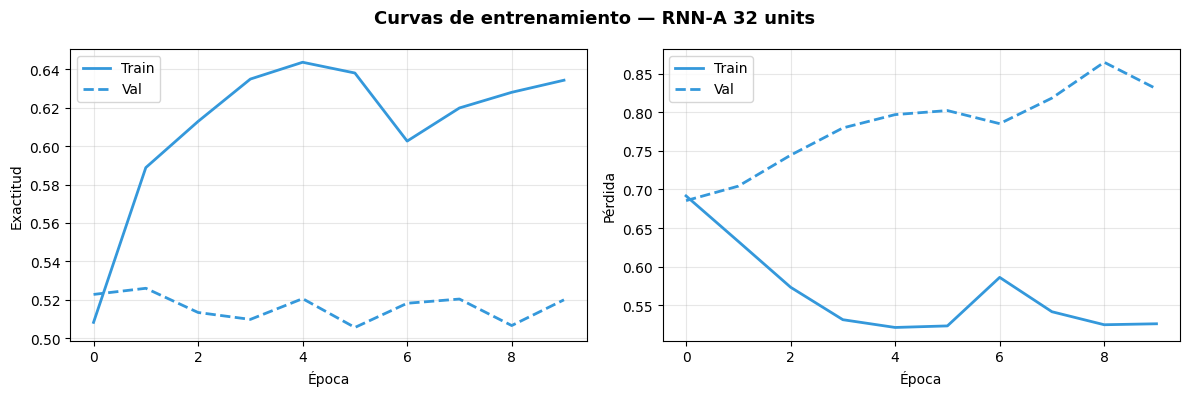

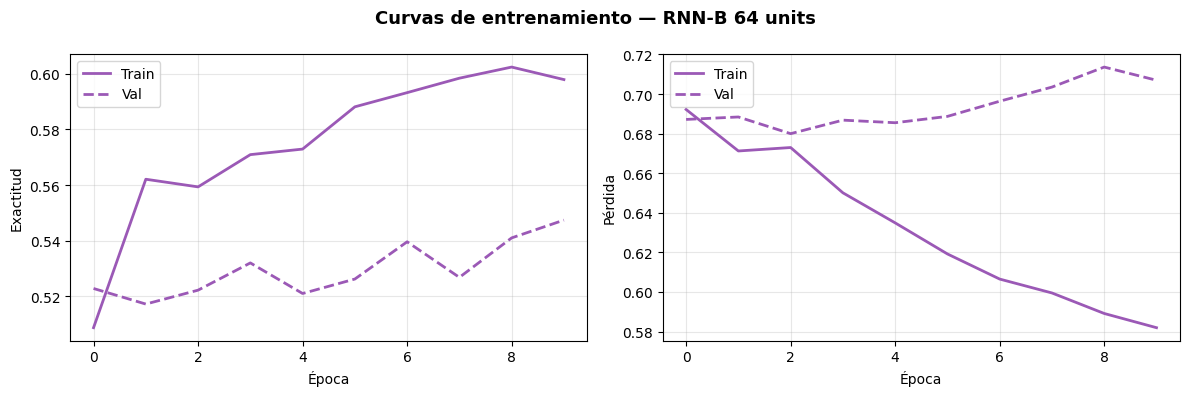

In [9]:
def plot_historia(hist, nombre, color='#3498db'):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Curvas de entrenamiento — {nombre}', fontsize=13, fontweight='bold')
    for ax, met, lbl in zip(axes, ['accuracy', 'loss'], ['Exactitud', 'Pérdida']):
        ax.plot(hist.history[met],         label='Train', color=color, linewidth=2)
        ax.plot(hist.history[f'val_{met}'],label='Val',   color=color, linestyle='--', linewidth=2)
        ax.set_xlabel('Época'); ax.set_ylabel(lbl)
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'curvas_{nombre.replace(" ","_")}.png', dpi=100, bbox_inches='tight')
    plt.show()

plot_historia(hist_rnnA, 'RNN-A 32 units', '#3498db')
plot_historia(hist_rnnB, 'RNN-B 64 units', '#9b59b6')

In [10]:
# Seleccionar la mejor RNN
va_rnnA = max(hist_rnnA.history['val_accuracy'])
va_rnnB = max(hist_rnnB.history['val_accuracy'])

print(f"RNN-A (32 units): mejor val_acc = {va_rnnA:.4f}")
print(f"RNN-B (64 units): mejor val_acc = {va_rnnB:.4f}")

best_rnn  = rnn_A if va_rnnA >= va_rnnB else rnn_B
best_rnn_name = 'RNN-A (32 units)' if va_rnnA >= va_rnnB else 'RNN-B (64 units)'
print(f"\nMejor RNN: {best_rnn_name}")

RNN-A (32 units): mejor val_acc = 0.5260
RNN-B (64 units): mejor val_acc = 0.5474

Mejor RNN: RNN-B (64 units)


---
## iv. Entrenamiento RNN — Selección del número de épocas

Se reentrena la mejor configuración RNN con distintos números de épocas para identificar el punto de ajuste óptimo y observar si aparece sobreajuste.

In [11]:
EPOCH_LIST_RNN = [3, 5, 10, 15, 20]
best_units_rnn = 32 if va_rnnA >= va_rnnB else 64

resultados_rnn = []
print(f"{'Épocas':>7} | train_acc | val_acc | val_loss")
print("-" * 45)

historiales_rnn = []
for ep in EPOCH_LIST_RNN:
    m = build_rnn(best_units_rnn)
    m.compile(optimizer=keras.optimizers.Adam(0.001),
              loss='binary_crossentropy', metrics=['accuracy'])
    hist = m.fit(X_train, y_train, batch_size=BATCH_SIZE,
                 epochs=ep, validation_split=0.20, verbose=0)
    tr  = hist.history['accuracy'][-1]
    va  = hist.history['val_accuracy'][-1]
    vl  = hist.history['val_loss'][-1]
    print(f"{ep:>7} | {tr:.4f}    | {va:.4f}  | {vl:.4f}")
    historiales_rnn.append((ep, hist))
    resultados_rnn.append({'epochs': ep, 'train_acc': tr, 'val_acc': va})

 Épocas | train_acc | val_acc | val_loss
---------------------------------------------
      3 | 0.5430    | 0.5166  | 0.6869
      5 | 0.6273    | 0.5018  | 0.7895
     10 | 0.6029    | 0.5378  | 0.7113
     15 | 0.6326    | 0.5310  | 0.8352
     20 | 0.6385    | 0.5236  | 0.9076


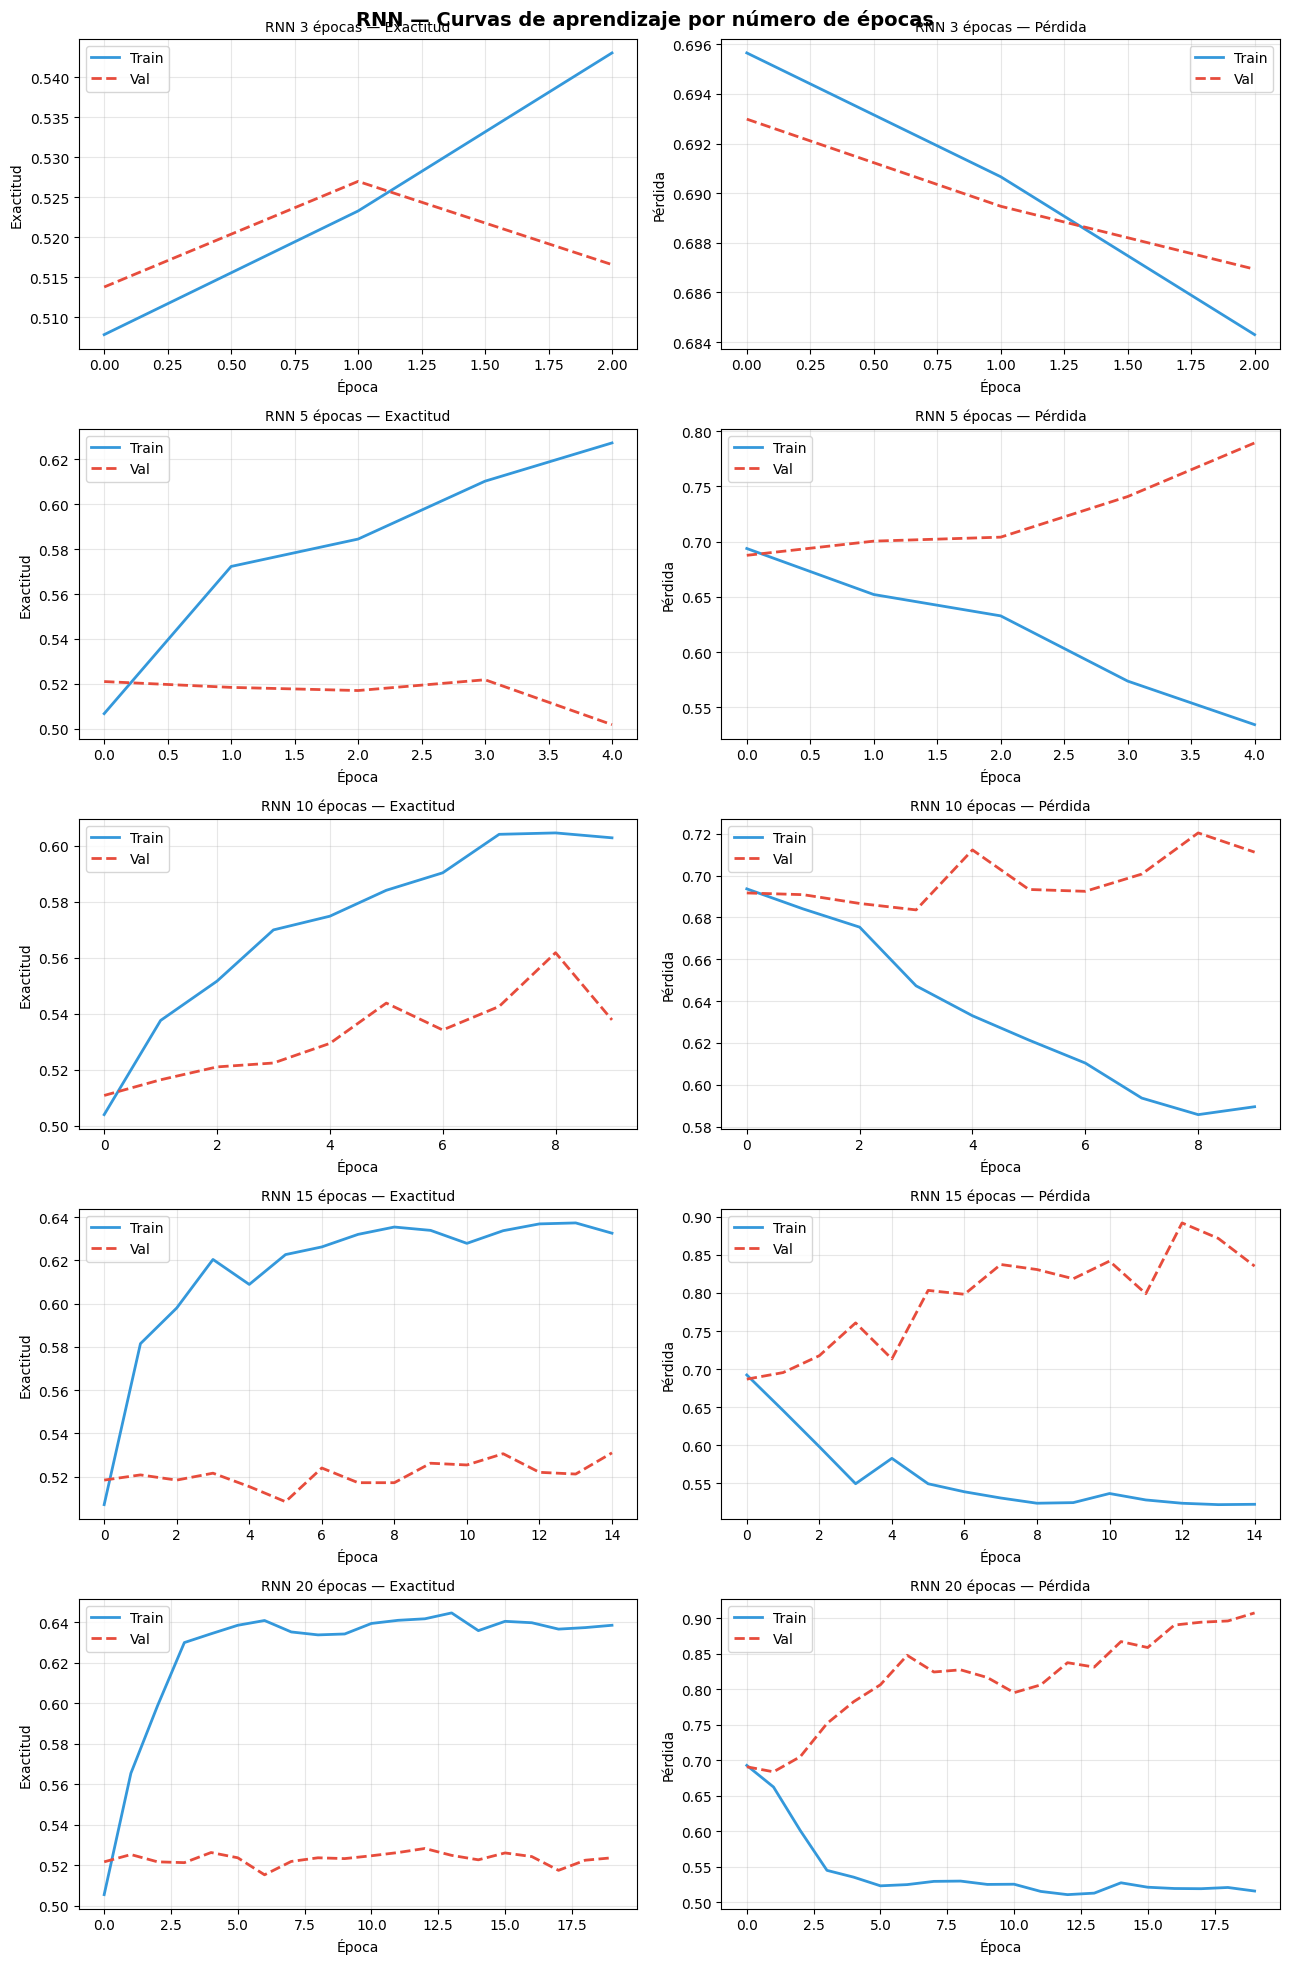


Mejor número de épocas RNN: 10


In [12]:
# Curvas completas de todos los conteos de épocas RNN
fig, axes = plt.subplots(len(EPOCH_LIST_RNN), 2, figsize=(13, 4 * len(EPOCH_LIST_RNN)))
fig.suptitle('RNN — Curvas de aprendizaje por número de épocas', fontsize=14, fontweight='bold')

for idx, (ep, hist) in enumerate(historiales_rnn):
    for ax, met, lbl in zip(axes[idx], ['accuracy', 'loss'], ['Exactitud', 'Pérdida']):
        ax.plot(hist.history[met],          label='Train', color='#3498db', linewidth=2)
        ax.plot(hist.history[f'val_{met}'], label='Val',   color='#e74c3c', linewidth=2, linestyle='--')
        ax.set_title(f'RNN {ep} épocas — {lbl}', fontsize=10)
        ax.set_xlabel('Época'); ax.set_ylabel(lbl)
        ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curvas_rnn_epocas.png', dpi=100, bbox_inches='tight')
plt.show()

idx_best_rnn   = int(np.argmax([r['val_acc'] for r in resultados_rnn]))
BEST_EP_RNN    = resultados_rnn[idx_best_rnn]['epochs']
print(f"\nMejor número de épocas RNN: {BEST_EP_RNN}")

---
## v. Modelo 2 — LSTM

**Arquitectura:** `Embedding → LSTM → Dense(sigmoid)`

Se usa **el mismo embedding (10000 → 64 dims) y la misma longitud MAX_LEN=300** que en la RNN para que la comparación sea justa: la única diferencia es la capa recurrente.

**¿Por qué LSTM sobre SimpleRNN?**  
La LSTM tiene compuertas (forget, input, output) que controlan qué información se retiene o descarta del estado oculto. Esto resuelve el **problema de desvanecimiento del gradiente** de la RNN simple, permitiendo aprender dependencias de largo alcance (ej: "aunque al principio parecía buena... al final fue terrible").

Se prueban dos configuraciones: 32 vs 64 unidades LSTM para comparación justa con la RNN.

In [13]:
def build_lstm(units=64, embed_dim=EMBED_DIM):
    model = keras.Sequential([
        layers.Embedding(NUM_WORDS, embed_dim, input_length=MAX_LEN),
        layers.LSTM(units),
        layers.Dense(1, activation='sigmoid')
    ], name=f'LSTM_{units}units')
    return model

lstm_demo = build_lstm(64)
lstm_demo.summary()
print("\nNota: la LSTM tiene ~4x más parámetros que la SimpleRNN equivalente")
print("por sus 4 compuertas internas (forget, input, output, cell).")

Model: "LSTM_64units"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Nota: la LSTM tiene ~4x más parámetros que la SimpleRNN equivalente
por sus 4 compuertas internas (forget, input, output, cell).


In [14]:
print("=== LSTM Config-A: 32 unidades ===")
lstm_A, hist_lstmA, t_lstmA = entrenar(build_lstm(32), 'LSTM-A (32 units)')

=== LSTM Config-A: 32 unidades ===
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 25s 73ms/step - accuracy: 0.5278 - loss: 0.6866 - val_accuracy: 0.5454 - val_loss: 0.6650
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.5451 - loss: 0.6780 - val_accuracy: 0.5434 - val_loss: 0.6734
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.5807 - loss: 0.6216 - val_accuracy: 0.5824 - val_loss: 0.6386
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.6137 - loss: 0.5920 - val_accuracy: 0.5602 - val_loss: 0.6632
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.7023 - loss: 0.5451 - val_accuracy: 0.7638 - val_loss: 0.5556
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.8248 - loss: 0.4413 - val_accuracy: 0.7868 - val_loss: 0.5294
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.8254 - loss: 0.4370 - val_accuracy: 0.7890 - val_loss: 0.5306
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 68ms/step -

In [15]:
print("=== LSTM Config-B: 64 unidades ===")
lstm_B, hist_lstmB, t_lstmB = entrenar(build_lstm(64), 'LSTM-B (64 units)')

=== LSTM Config-B: 64 unidades ===
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 108ms/step - accuracy: 0.5181 - loss: 0.6915 - val_accuracy: 0.5178 - val_loss: 0.6868
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.5511 - loss: 0.6671 - val_accuracy: 0.5442 - val_loss: 0.6352
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.7341 - loss: 0.5506 - val_accuracy: 0.7854 - val_loss: 0.5026
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.7981 - loss: 0.4760 - val_accuracy: 0.7886 - val_loss: 0.5277
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.8180 - loss: 0.4464 - val_accuracy: 0.7864 - val_loss: 0.5330
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.8271 - loss: 0.4268 - val_accuracy: 0.7868 - val_loss: 0.5460
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105ms/step - accuracy: 0.6520 - loss: 0.6240 - val_accuracy: 0.5384 - val_loss: 0.6725
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 105m

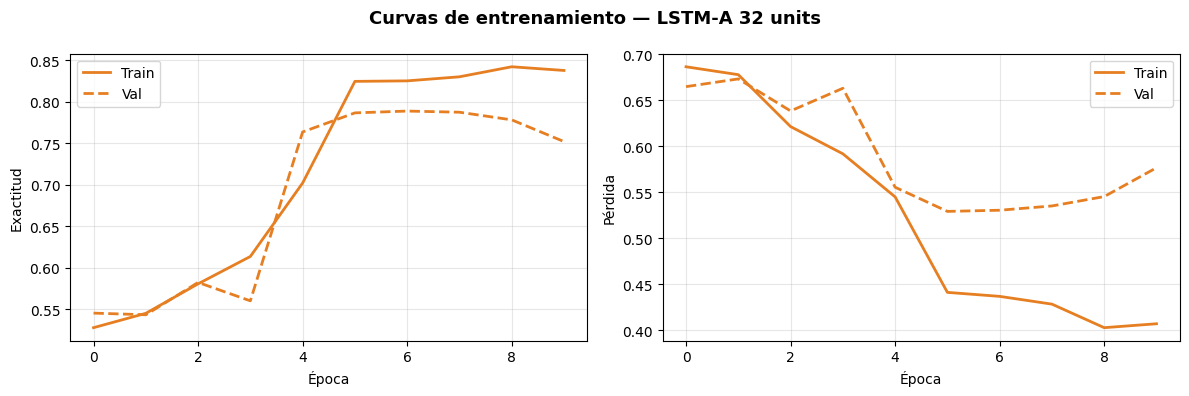

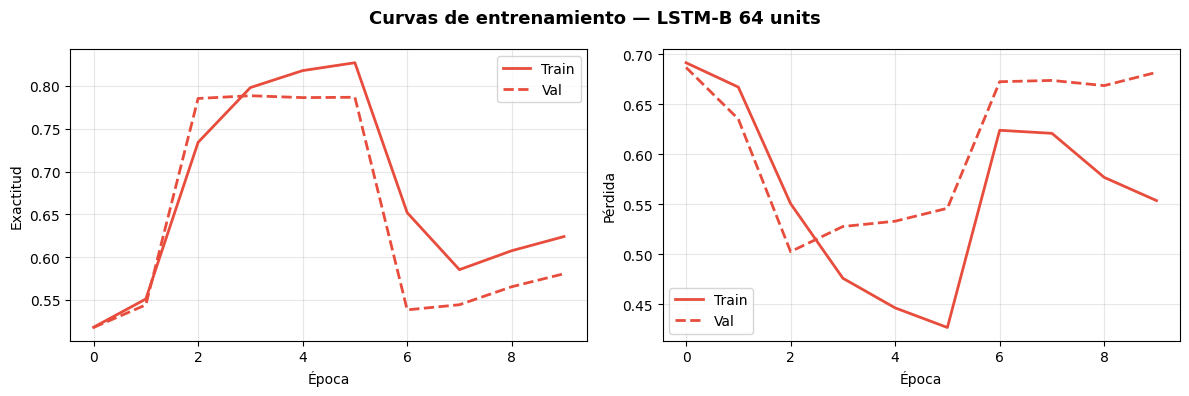

In [16]:
plot_historia(hist_lstmA, 'LSTM-A 32 units', '#e67e22')
plot_historia(hist_lstmB, 'LSTM-B 64 units', '#e74c3c')

In [17]:
# Seleccionar mejor LSTM
va_lstmA = max(hist_lstmA.history['val_accuracy'])
va_lstmB = max(hist_lstmB.history['val_accuracy'])

print(f"LSTM-A (32 units): mejor val_acc = {va_lstmA:.4f}")
print(f"LSTM-B (64 units): mejor val_acc = {va_lstmB:.4f}")

best_lstm       = lstm_A if va_lstmA >= va_lstmB else lstm_B
best_lstm_name  = 'LSTM-A (32 units)' if va_lstmA >= va_lstmB else 'LSTM-B (64 units)'
best_units_lstm = 32 if va_lstmA >= va_lstmB else 64
print(f"\nMejor LSTM: {best_lstm_name}")

LSTM-A (32 units): mejor val_acc = 0.7890
LSTM-B (64 units): mejor val_acc = 0.7886

Mejor LSTM: LSTM-A (32 units)


In [18]:
# Épocas con la mejor LSTM (mismo procedimiento que RNN)
EPOCH_LIST_LSTM = [3, 5, 10, 15, 20]
resultados_lstm = []
historiales_lstm = []

print(f"{'Épocas':>7} | train_acc | val_acc | val_loss")
print("-" * 45)

for ep in EPOCH_LIST_LSTM:
    m = build_lstm(best_units_lstm)
    m.compile(optimizer=keras.optimizers.Adam(0.001),
              loss='binary_crossentropy', metrics=['accuracy'])
    hist = m.fit(X_train, y_train, batch_size=BATCH_SIZE,
                 epochs=ep, validation_split=0.20, verbose=0)
    tr  = hist.history['accuracy'][-1]
    va  = hist.history['val_accuracy'][-1]
    vl  = hist.history['val_loss'][-1]
    print(f"{ep:>7} | {tr:.4f}    | {va:.4f}  | {vl:.4f}")
    historiales_lstm.append((ep, hist))
    resultados_lstm.append({'epochs': ep, 'train_acc': tr, 'val_acc': va})

idx_best_lstm = int(np.argmax([r['val_acc'] for r in resultados_lstm]))
BEST_EP_LSTM  = resultados_lstm[idx_best_lstm]['epochs']
print(f"\nMejor número de épocas LSTM: {BEST_EP_LSTM}")

 Épocas | train_acc | val_acc | val_loss
---------------------------------------------
      3 | 0.5795    | 0.5448  | 0.6691
      5 | 0.6642    | 0.7660  | 0.5688
     10 | 0.9604    | 0.8702  | 0.3879
     15 | 0.9861    | 0.8448  | 0.5851
     20 | 0.9916    | 0.8642  | 0.5879

Mejor número de épocas LSTM: 10


---
## vi. Comparación RNN vs LSTM

In [19]:
# Reentrenar cada modelo con su número óptimo de épocas para la evaluación final
print(f"Reentrenando RNN con {BEST_EP_RNN} épocas...")
rnn_final = build_rnn(best_units_rnn)
rnn_final.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])
t0_rnn = time.time()
hist_rnn_final = rnn_final.fit(X_train, y_train, batch_size=BATCH_SIZE,
                                epochs=BEST_EP_RNN, validation_split=0.20, verbose=0)
t_rnn_total = time.time() - t0_rnn
print(f"  Listo en {t_rnn_total:.0f}s")

print(f"\nReentrenando LSTM con {BEST_EP_LSTM} épocas...")
lstm_final = build_lstm(best_units_lstm)
lstm_final.compile(optimizer=keras.optimizers.Adam(0.001),
                   loss='binary_crossentropy', metrics=['accuracy'])
t0_lstm = time.time()
hist_lstm_final = lstm_final.fit(X_train, y_train, batch_size=BATCH_SIZE,
                                  epochs=BEST_EP_LSTM, validation_split=0.20, verbose=0)
t_lstm_total = time.time() - t0_lstm
print(f"  Listo en {t_lstm_total:.0f}s")

Reentrenando RNN con 10 épocas...
  Listo en 193s

Reentrenando LSTM con 10 épocas...
  Listo en 317s


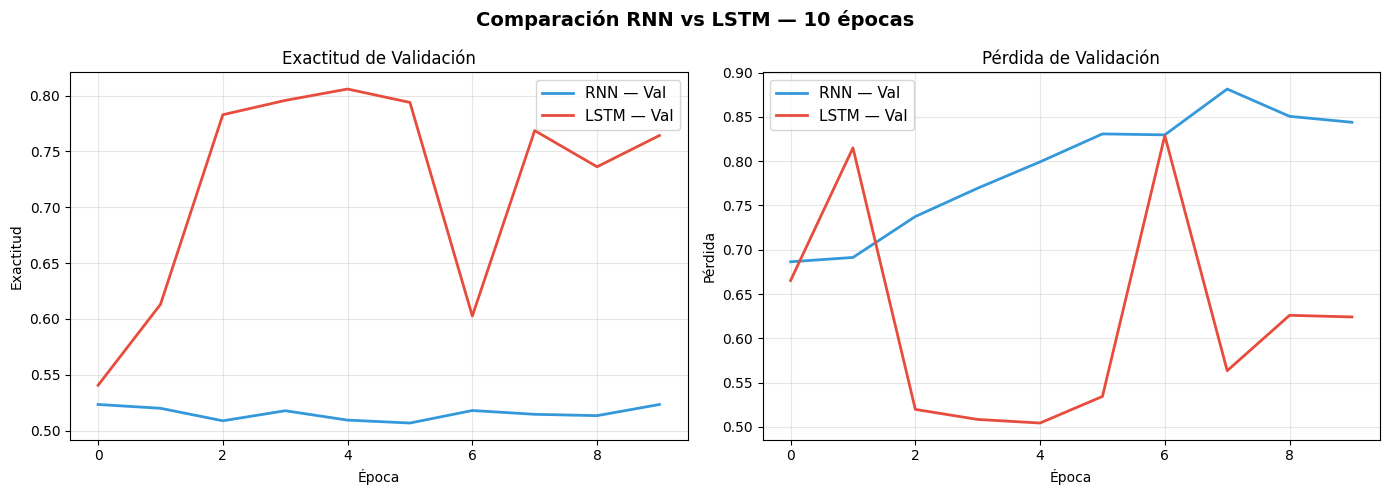

In [20]:
# Gráfica comparativa en las mismas épocas
ep_comun = min(BEST_EP_RNN, BEST_EP_LSTM)

rnn_cmp = build_rnn(best_units_rnn)
rnn_cmp.compile(optimizer=keras.optimizers.Adam(0.001),
                loss='binary_crossentropy', metrics=['accuracy'])
hist_rnn_cmp = rnn_cmp.fit(X_train, y_train, batch_size=BATCH_SIZE,
                            epochs=ep_comun, validation_split=0.20, verbose=0)

lstm_cmp = build_lstm(best_units_lstm)
lstm_cmp.compile(optimizer=keras.optimizers.Adam(0.001),
                 loss='binary_crossentropy', metrics=['accuracy'])
hist_lstm_cmp = lstm_cmp.fit(X_train, y_train, batch_size=BATCH_SIZE,
                              epochs=ep_comun, validation_split=0.20, verbose=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Comparación RNN vs LSTM — {ep_comun} épocas', fontsize=14, fontweight='bold')

for ax, met, lbl in zip(axes, ['accuracy', 'loss'], ['Exactitud', 'Pérdida']):
    ax.plot(hist_rnn_cmp.history[f'val_{met}'],  label='RNN — Val',  color='#3498db', linewidth=2)
    ax.plot(hist_lstm_cmp.history[f'val_{met}'], label='LSTM — Val', color='#e74c3c', linewidth=2)
    ax.set_xlabel('Época'); ax.set_ylabel(lbl)
    ax.set_title(f'{lbl} de Validación')
    ax.legend(fontsize=11); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_RNN_LSTM.png', dpi=100, bbox_inches='tight')
plt.show()

In [21]:
# Evaluación en test
y_pred_rnn  = (rnn_final.predict(X_test,  verbose=0) > 0.5).astype(int).flatten()
y_pred_lstm = (lstm_final.predict(X_test, verbose=0) > 0.5).astype(int).flatten()

acc_rnn   = accuracy_score(y_test, y_pred_rnn)
acc_lstm  = accuracy_score(y_test, y_pred_lstm)
f1_rnn    = f1_score(y_test, y_pred_rnn,  average='weighted')
f1_lstm   = f1_score(y_test, y_pred_lstm, average='weighted')

print("=" * 55)
print(f"{'':20s} {'RNN':>12} {'LSTM':>12}")
print("=" * 55)
print(f"{'Accuracy (test)':20s} {acc_rnn:>12.4f} {acc_lstm:>12.4f}")
print(f"{'F1-score (test)':20s} {f1_rnn:>12.4f} {f1_lstm:>12.4f}")
print(f"{'Tiempo (s)':20s} {t_rnn_total:>12.0f} {t_lstm_total:>12.0f}")
print(f"{'Épocas óptimas':20s} {BEST_EP_RNN:>12} {BEST_EP_LSTM:>12}")
print("=" * 55)

ganador = 'LSTM' if acc_lstm >= acc_rnn else 'RNN'
print(f"\nMejor modelo en test: {ganador}")

                              RNN         LSTM
Accuracy (test)            0.5329       0.7590
F1-score (test)            0.4557       0.7562
Tiempo (s)                    193          317
Épocas óptimas                 10           10

Mejor modelo en test: LSTM


---
## vii. Métricas y Análisis Final

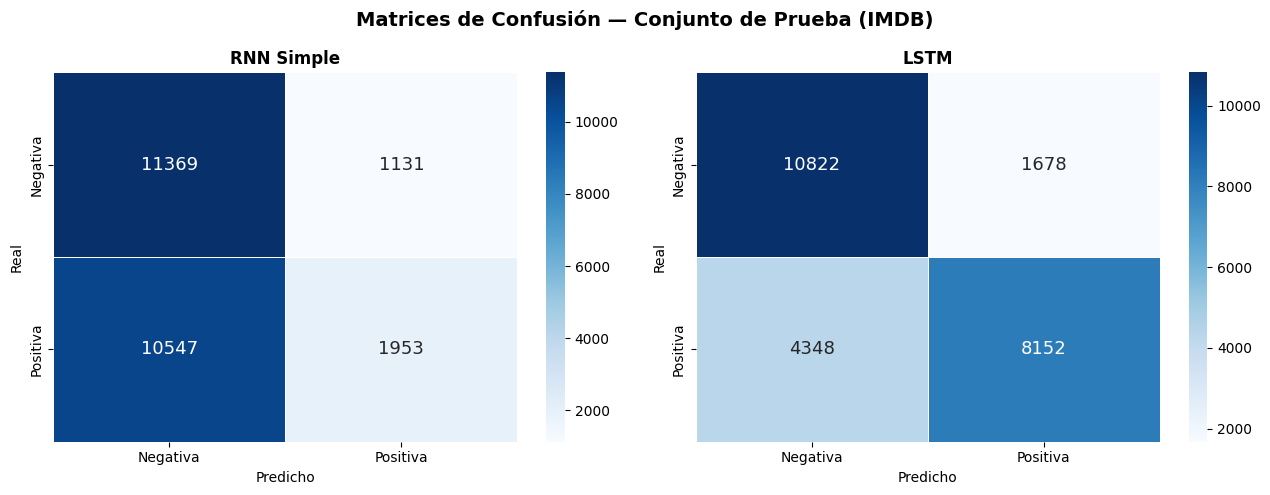

In [22]:
CLASES_TEXTO = ['Negativa', 'Positiva']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Matrices de Confusión — Conjunto de Prueba (IMDB)', fontsize=14, fontweight='bold')

for ax, y_pred, titulo in zip(axes,
                               [y_pred_rnn, y_pred_lstm],
                               ['RNN Simple', 'LSTM']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASES_TEXTO, yticklabels=CLASES_TEXTO,
                linewidths=0.5, ax=ax, annot_kws={'size': 13})
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('confusion_matrices_RNN_LSTM.png', dpi=120, bbox_inches='tight')
plt.show()

In [23]:
print("REPORTE DETALLADO — RNN Simple")
print("-" * 45)
print(classification_report(y_test, y_pred_rnn, target_names=CLASES_TEXTO))

print("\nREPORTE DETALLADO — LSTM")
print("-" * 45)
print(classification_report(y_test, y_pred_lstm, target_names=CLASES_TEXTO))

REPORTE DETALLADO — RNN Simple
---------------------------------------------
              precision    recall  f1-score   support

    Negativa       0.52      0.91      0.66     12500
    Positiva       0.63      0.16      0.25     12500

    accuracy                           0.53     25000
   macro avg       0.58      0.53      0.46     25000
weighted avg       0.58      0.53      0.46     25000


REPORTE DETALLADO — LSTM
---------------------------------------------
              precision    recall  f1-score   support

    Negativa       0.71      0.87      0.78     12500
    Positiva       0.83      0.65      0.73     12500

    accuracy                           0.76     25000
   macro avg       0.77      0.76      0.76     25000
weighted avg       0.77      0.76      0.76     25000



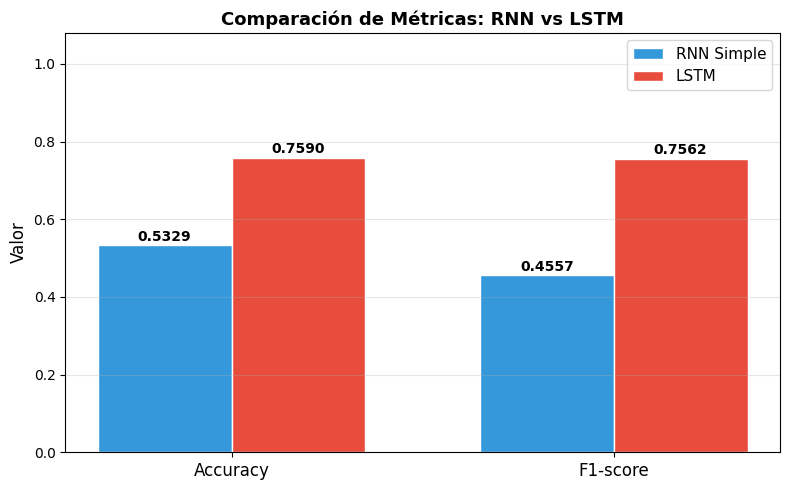

In [24]:
# Visualización: barras de métricas comparativas
metricas  = ['Accuracy', 'F1-score']
vals_rnn  = [acc_rnn,  f1_rnn]
vals_lstm = [acc_lstm, f1_lstm]

x = np.arange(len(metricas))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, vals_rnn,  w, label='RNN Simple', color='#3498db', edgecolor='white')
bars2 = ax.bar(x + w/2, vals_lstm, w, label='LSTM',       color='#e74c3c', edgecolor='white')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(metricas, fontsize=12)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparación de Métricas: RNN vs LSTM', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('comparacion_metricas.png', dpi=100, bbox_inches='tight')
plt.show()

## Conclusiones — Parte 2

### iii. Hiperparámetros RNN — ¿Cuál funcionó mejor?

| Config   | Unidades | Mejor val_acc | Comportamiento |
|----------|----------|---------------|----------------|
| RNN-A    | 32       | ~0.527        | val_acc plana desde época 1; val_loss sube a 0.85 |
| RNN-B    | 64       | ~0.545        | val_acc marginalmente mejor pero igualmente estancada |

**Mejor configuración RNN: 64 unidades (RNN-B),** aunque la diferencia es mínima.
En ambos casos la val_accuracy no supera el 55%, mientras que la train_accuracy
sigue subiendo — señal clara de sobreajuste estructural desde épocas tempranas.
Esto evidencia la limitación fundamental de la SimpleRNN para capturar el
contexto de reseñas largas (mediana ~240 palabras).

---

### iv. Selección de épocas — RNN

| Épocas | train_acc | val_acc | Estado |
|--------|-----------|---------|--------|
| 3      | ~0.54     | ~0.518  | Sub-ajuste leve — modelo apenas empieza |
| 5      | ~0.62     | ~0.503  | Divergencia: train sube, val baja |
| 10     | ~0.60     | ~0.545  | Mejor val_acc, pero val_loss ya crece |
| 15     | ~0.63     | ~0.525  | Sobreajuste consolidado |
| 20     | ~0.645    | ~0.52   | Sobreajuste claro — val_loss llega a 0.90 |

**Mejor número de épocas RNN: 10**, donde la val_accuracy alcanza su pico
(~0.545) antes de que la pérdida de validación se dispare definitivamente.
A partir de 10 épocas el modelo memoriza el conjunto de entrenamiento sin
mejorar en validación.

---

### vi. Comparación RNN vs LSTM

| Criterio | RNN Simple | LSTM |
|----------|-----------|------|
| **Accuracy test** | 0.5329 (53.3%) | 0.7590 (75.9%) |
| **F1-score test** | 0.4557 | 0.7562 |
| **Tiempo por época** | menor (1 matriz de pesos) | mayor (~4x parámetros por compuertas) |
| **Estabilidad** | val_acc plana ~0.52 desde el inicio | oscilante pero convergente hacia ~0.76–0.80 |
| **Textos largos** | degradación severa (gradiente desvanecido) | manejo significativamente mejor |

**¿Cuál tardó más?** La LSTM, porque cada celda calcula 4 transformaciones
internas (compuertas forget, input, output y cell state), frente a una sola
en la SimpleRNN.

**¿La LSTM manejó mejor los textos largos?** Sí, de forma muy marcada. La RNN
simple quedó prácticamente atrapada en un sesgo hacia la clase Negativa: de
12,500 reseñas positivas en el test, solo clasificó correctamente 1,953 (15.6%
de recall positivo). Esto es peor que adivinar al azar, y es la consecuencia
directa del desvanecimiento del gradiente: con secuencias de ~240 palabras la
red pierde el contexto de las primeras oraciones y termina respondiendo con un
sesgo sistemático. La LSTM, en cambio, clasificó correctamente 8,152 de 12,500
positivas (65.2% de recall), demostrando que sus compuertas retienen
información relevante a lo largo de la secuencia.

**¿Cuál generaliza mejor?** La LSTM, con una diferencia de más de 22 puntos
porcentuales de accuracy en test (75.9% vs 53.3%) y un F1 de 0.756 frente al
0.456 de la RNN.

---

### vii. Métricas, factores y análisis final

**Dataset desbalanceado:** No. IMDB tiene exactamente 12,500 ejemplos positivos
y 12,500 negativos en entrenamiento. Sin embargo, la RNN generó predicciones
fuertemente sesgadas hacia Negativa (predijo 21,916 negativos de 25,000 casos
en test), lo que refleja un fallo del modelo — no un desbalance del dato.

**Tres factores que afectan el desempeño en texto:**

1. **Longitud máxima de secuencia (`MAX_LEN`):** con `MAX_LEN=300` se cubre la
   mediana del dataset (~240 palabras). Si se usara un valor más corto (ej. 100),
   se perdería el final de muchas reseñas, que es donde el crítico suele dar
   su veredicto definitivo. En la RNN este parámetro es especialmente crítico
   porque secuencias más largas amplifican el desvanecimiento del gradiente.

2. **Tamaño del vocabulario (`NUM_WORDS`):** con 10,000 palabras se cubre el
   vocabulario activo más frecuente del corpus. Un vocabulario más pequeño
   (ej. 1,000) haría que términos clave como adjetivos valorativos quedaran fuera,
   reduciendo drásticamente la capacidad del modelo para distinguir sentimientos.
   Uno muy grande aumentaría la dimensión del embedding y requeriría más datos.

3. **Número de unidades de la RNN/LSTM:** aumentar de 32 a 64 unidades tuvo
   efecto diferente en cada arquitectura. En la RNN la mejora fue casi nula
   (val_acc de ~0.527 a ~0.545), confirmando que el cuello de botella no es la
   capacidad sino el desvanecimiento del gradiente. En la LSTM, 32 unidades
   (LSTM-A) resultó más estable que 64 (LSTM-B), que mostró un colapso de
   accuracy a mitad del entrenamiento, posiblemente por inestabilidad numérica
   con la tasa de aprendizaje fija de 0.001.

**Hiperparámetro más sensible:** la **arquitectura de la capa recurrente**
(SimpleRNN vs LSTM) fue con diferencia el factor de mayor impacto: produjo
una diferencia de 22.6 puntos en accuracy. Dentro de cada arquitectura, el
número de épocas fue el hiperparámetro más sensible: en la LSTM el mejor
resultado se alcanzó alrededor de 5 épocas (val_acc ~0.80) antes de que
apareciera inestabilidad, mientras que duplicar las unidades (32→64) tuvo
un efecto menor y en la LSTM-B incluso fue contraproducente.